# 04 Evaluation

In [1]:
%matplotlib inline
import os, warnings
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error
warnings.filterwarnings("ignore")

import sys
from pathlib import Path

for candidate in [Path.cwd(), Path.cwd() / "notebooks" / "models", Path.cwd().parent / "models"]:
    if (candidate / "data_loader_00.py").exists():
        candidate_str = str(candidate.resolve())
        if candidate_str not in sys.path:
            sys.path.insert(0, candidate_str)
        break

from data_loader_00 import PROJECT_DIR, load_processed_data, get_Xy

OUTPUT_DIR = os.path.join(PROJECT_DIR, "outputs", "evaluation")
os.makedirs(OUTPUT_DIR, exist_ok=True)
RANDOM_SEED = 42
N_BOOTSTRAP = 300
TARGET = "weekly_units"

In [2]:
def bootstrap_metrics(y_true, y_pred, n_iter=N_BOOTSTRAP):
    y_true = np.array(y_true, dtype=float)
    y_pred = np.array(y_pred, dtype=float)
    rng = np.random.default_rng(RANDOM_SEED)
    maes, rmses, mapes = [], [], []
    for _ in range(n_iter):
        idx = rng.integers(0, len(y_true), size=len(y_true))
        yt, yp = y_true[idx], y_pred[idx]
        maes.append(mean_absolute_error(yt, yp))
        rmses.append(np.sqrt(mean_squared_error(yt, yp)))
        mapes.append(np.mean(np.abs((yt - yp) / np.where(yt == 0, 1, yt))) * 100)
    def ci(arr):
        arr = np.array(arr)
        return arr.mean(), np.percentile(arr, 2.5), np.percentile(arr, 97.5)
    mae_m, mae_lo, mae_hi = ci(maes)
    rmse_m, rmse_lo, rmse_hi = ci(rmses)
    mape_m, mape_lo, mape_hi = ci(mapes)
    return {
        "MAE": round(mae_m, 2), "MAE_lo": round(mae_lo, 2), "MAE_hi": round(mae_hi, 2),
        "RMSE": round(rmse_m, 2), "RMSE_lo": round(rmse_lo, 2), "RMSE_hi": round(rmse_hi, 2),
        "MAPE": round(mape_m, 3), "MAPE_lo": round(mape_lo, 3), "MAPE_hi": round(mape_hi, 3),
    }

def naive_preds_from_features(test: pd.DataFrame):
    y_true = test[TARGET].values
    return {
        "Naive: Last Week": (y_true, test["lag_1"].values),
        "Naive: 4-Week Rolling Avg": (y_true, test["rolling_mean_4"].values),
        "Naive: Last Year": (y_true, test["lag_52"].values),
    }

def _load_prediction_csv(path: str):
    if not os.path.exists(path):
        return None, None
    df = pd.read_csv(path, parse_dates=["week_start"])
    return df["actual"].values.astype(float), df["predicted"].values.astype(float)

In [3]:
train, valid, test, feature_cols = load_processed_data(valid_weeks=8)
X_te, y_te = get_Xy(test, feature_cols)
results_rows = []

for name, (yt, yp) in naive_preds_from_features(test).items():
    mask = ~(np.isnan(yt) | np.isnan(yp))
    m = bootstrap_metrics(yt[mask], yp[mask])
    m["model"] = name
    results_rows.append(m)

rf_path = os.path.join(os.getcwd(), "outputs", "rf_pooled_best_model.joblib")
if os.path.exists(rf_path):
    rf = joblib.load(rf_path)
    rf_preds = rf.predict(X_te)
    m = bootstrap_metrics(y_te, rf_preds)
    m["model"] = "RandomForest (Pooled)"
    results_rows.append(m)

lgbm_path = os.path.join(os.getcwd(), "outputs", "lgbm_pooled_best_model.joblib")
if os.path.exists(lgbm_path):
    lgbm = joblib.load(lgbm_path)
    lgbm_preds = lgbm.predict(X_te)
    m = bootstrap_metrics(y_te, lgbm_preds)
    m["model"] = "LightGBM (Pooled)"
    results_rows.append(m)

rf_pred_path = os.path.join(os.getcwd(), "outputs", "rf_percombo_predictions.csv")
yt_rf_combo, yp_rf_combo = _load_prediction_csv(rf_pred_path)
if yt_rf_combo is not None:
    m = bootstrap_metrics(yt_rf_combo, yp_rf_combo)
    m["model"] = "RandomForest (PerCombo)"
    results_rows.append(m)

lgbm_pred_path = os.path.join(os.getcwd(), "outputs", "lgbm_percombo_predictions.csv")
yt_lgbm_combo, yp_lgbm_combo = _load_prediction_csv(lgbm_pred_path)
if yt_lgbm_combo is not None:
    m = bootstrap_metrics(yt_lgbm_combo, yp_lgbm_combo)
    m["model"] = "LightGBM (PerCombo)"
    results_rows.append(m)

results_df = pd.DataFrame(results_rows)
results_df = results_df[["model", "MAE", "MAE_lo", "MAE_hi", "RMSE", "RMSE_lo", "RMSE_hi", "MAPE", "MAPE_lo", "MAPE_hi"]]
results_df = results_df.sort_values("MAE").reset_index(drop=True)
results_df

[load] Train=6,270 | Valid=240 | Test=240 | Features=23


,model,MAE,MAE_lo,MAE_hi,RMSE,RMSE_lo,RMSE_hi,MAPE,MAPE_lo,MAPE_hi
0,RandomForest (Pooled),446.69,364.79,516.74,774.87,603.44,948.80,4.474,4.071,4.887
1,LightGBM (Pooled),457.47,378.80,542.81,815.74,612.58,1037.02,4.529,4.102,4.967
2,Naive: 4-Week Rolling Avg,578.41,472.90,686.51,1099.13,826.63,1365.66,4.967,4.513,5.454
3,RandomForest (PerCombo),586.78,478.56,699.12,1080.42,828.47,1296.84,5.628,5.069,6.151
4,Naive: Last Week,653.61,517.22,794.08,1342.40,894.08,1755.93,6.016,5.368,6.687
5,Naive: Last Year,1533.92,1187.40,1880.03,3079.02,2399.54,3691.57,12.535,10.991,14.056


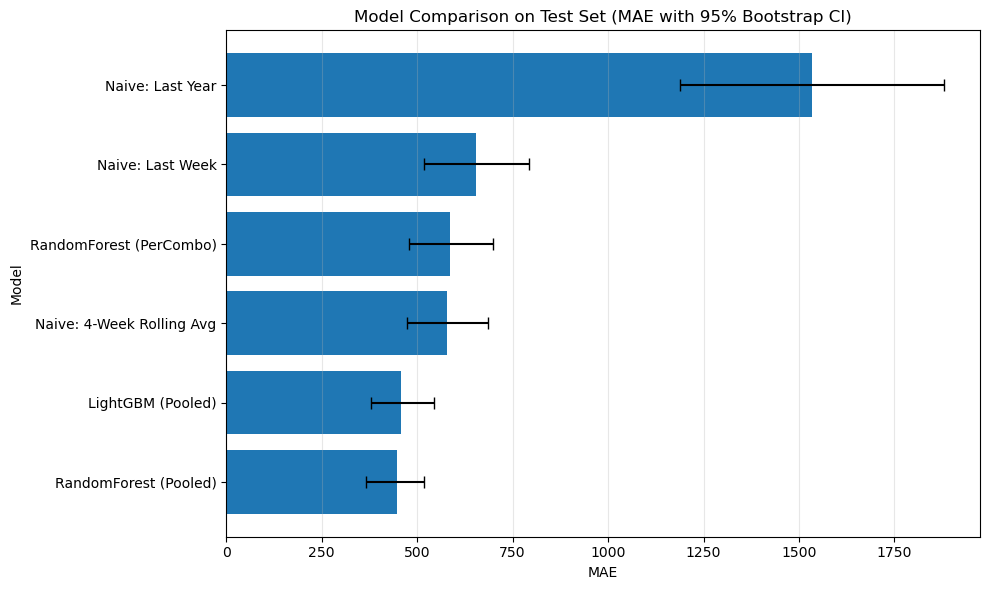

In [4]:
df_plot = results_df.sort_values("MAE").reset_index(drop=True)
mae_err_low = df_plot["MAE"] - df_plot["MAE_lo"]
mae_err_high = df_plot["MAE_hi"] - df_plot["MAE"]

plt.figure(figsize=(10, 6))
plt.barh(
    df_plot["model"],
    df_plot["MAE"],
    xerr=[mae_err_low, mae_err_high],
    capsize=4
)
plt.title("Model Comparison on Test Set (MAE with 95% Bootstrap CI)")
plt.xlabel("MAE")
plt.ylabel("Model")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

In [5]:
results_df.to_csv(os.path.join(OUTPUT_DIR, "model_comparison_table.csv"), index=False)
print("Saved evaluation outputs.")

Saved evaluation outputs.
